# Modular RAG 실습

In [28]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# 1. 기존 메모리의 키 삭제
if "OPENAI_API_KEY" in os.environ:
    del os.environ["OPENAI_API_KEY"]

# 2. .env 파일 새로고침 (반드시 override=True)
load_dotenv(override=True)

# 3. 모델 객체 재생성 (이때 최신 키가 주입됩니다)
# 모델명은 실제 사용하시는 것에 맞게 수정하세요.
llm = ChatOpenAI(model="gpt-4o", temperature=0)
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

print(f"✅ 모델 생성 완료 (현재 키 끝자리: {os.getenv('OPENAI_API_KEY')[-4:]})")

✅ 모델 생성 완료 (현재 키 끝자리: yUEA)


In [29]:
from dotenv import load_dotenv
import os
load_dotenv()

from langgraph.graph import StateGraph, END, START
from typing import TypedDict, List
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_pinecone import PineconeVectorStore
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM 초기화
llm    = ChatOpenAI(model="gpt-4o-mini", temperature=0)
parser = StrOutputParser()

# Pinecone 연결
embeddings  = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = PineconeVectorStore.from_existing_index(
    index_name="finance-bok",
    embedding=embeddings,
    namespace="bok-ns1"
)
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3, "namespace": "bok-ns1"}
)

print("초기화 완료")

초기화 완료


## state 정의

In [30]:
class FinanceRAGState(TypedDict):
    query:           str           # 사용자 원본 질문
    rewritten_query: str           # 재작성된 검색 질문
    docs:            List[Document] # 검색된 문서
    answer:          str           # 최종 답변
    retry_count:     int           # 재시도 횟수 (최대 2회)
    doc_grade:       str           # 문서 품질 평가 결과 ("good" / "bad")

## Rewrite 프롬프트 정의

In [31]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 금융 검색 전문가입니다.
사용자의 질문을 한국은행 경제전망 보고서 검색에 최적화된 형태로 재작성하세요.
재작성된 질문만 출력하세요."""),
    ("human", "{query}")
])
rewrite_chain = rewrite_prompt | llm | parser

## Rewrite 노드 정의

In [32]:
def rewrite_node(state: FinanceRAGState):
  # 재작성 체인을 이용해 새로운 쿼리를 작성합니다.
    rewritten = rewrite_chain.invoke({"query": state["query"]})
    print(f"[rewrite] {rewritten}")
    # STATE에 새로운 쿼리를 저장합니다.
    # RETRY_CNT=0 초기화
    return {
        "rewritten_query": rewritten,
        "retry_count": state.get("retry_count", 0)
    }

## Retrieve 노드 정의

In [33]:
def retrieve_node(state: FinanceRAGState):
    # 벡터DB에 연결된 리트리버를 이용해 재작성한 쿼리로 검색 실행
    docs = retriever.invoke(state["rewritten_query"])
    print(f"[retrieve] {len(docs)}개 문서 검색")
    #래그 검색 결과 문서를 STATE에 저장
    return {"docs": docs}

## Grade 노드 정의
LLM 이용해서 좋음과 나쁨 판정하는 체인 정의

In [34]:
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 검색 문서의 품질을 평가하는 전문가입니다.
아래 질문과 검색된 문서를 보고 문서가 질문에 답변하기에 충분한지 평가하세요.
충분하면 "good", 불충분하면 "bad"만 출력하세요."""),
    ("human", """질문: {query}

검색된 문서:
{context}""")
])
grade_chain = grade_prompt | llm | parser

## Grade 노드 만들기

In [35]:
def grade_node(state: FinanceRAGState):
  # 컨텍스트에 검색결과 문서를 추가합니다.
    context = "\n\n".join([doc.page_content for doc in state["docs"]])
    grade= grade_chain.invoke({
        "query":   state["query"],
        "context": context
    }).strip().lower()  #good/bad로 출력
    print(f"[grade] 품질 평가 결과: {grade} (재시도 횟수: {state.get('retry_count', 0)})")
    
    #평가결과 (grade)를 state에 저장
    return {"doc_grade": grade}

## generate  답변 생성

In [36]:
generate_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 한국은행 경제전망 보고서 전문 애널리스트입니다.
아래 참고 문서를 바탕으로 질문에 정확하게 답하세요.
문서에 없는 내용은 "보고서에서 확인되지 않습니다"라고 답하세요.

[참고 문서]
{context}"""),
    ("human", "{question}")
])
generate_chain = generate_prompt | llm | parser

def generate_node(state: FinanceRAGState):
    context = "\n\n".join([doc.page_content for doc in state["docs"]])
    
    # 사용자 원본 쿼리+검색결과를 이용해 최종답변 생성
    answer  = generate_chain.invoke({
        "context":  context,
        "question": state["query"]
    })
    print(f"[generate] 답변 생성 완료")
    return {"answer": answer}

## 쿼리 실패 처리
if retry_cnt>2
답변생성 노드 실행, 주의문 추가

In [37]:
def fallback_node(state: FinanceRAGState):
    print(f"[fallback] 재시도 초과 → 일반 답변 생성")
    
    # 생성 노드 호출
    answer = generate_chain.invoke({
        "context":  "\n\n".join([doc.page_content for doc in state["docs"]]),
        "question": state["query"]
    })
    return {"answer": f"[참고: 검색 품질이 낮을 수 있습니다]\n{answer}"}

## 재시도 노드
if 품질평가 결과 = BAD
   retry_cnt +=1
   rewrite_chain 호출

In [38]:
def rewrite_retry_node(state: FinanceRAGState):
    retry     = state.get("retry_count", 0) + 1
    rewritten = rewrite_chain.invoke({"query": state["query"]})
    print(f"[rewrite_retry] 재시도 {retry}회 → {rewritten}")
    return {
        "rewritten_query": rewritten,
        "retry_count":     retry
    }

## 라우터 함수 정의

In [39]:
def route_after_grade(state: FinanceRAGState) -> str:
    if state["doc_grade"] == "good":
        return "generate"

    retry = state.get("retry_count", 0)
    if retry >= 2:
        return "fallback"

    return "rewrite_retry"

## 노드 등록

In [40]:
graph = StateGraph(FinanceRAGState)

# Node 등록
graph.add_node("rewrite",       rewrite_node)
graph.add_node("retrieve",      retrieve_node)
graph.add_node("grade",         grade_node)
graph.add_node("generate",      generate_node)
graph.add_node("fallback",      fallback_node)
graph.add_node("rewrite_retry", rewrite_retry_node)

## Edge 연결

In [41]:
# Edge 연결
graph.add_edge(START,      "rewrite")
graph.add_edge("rewrite",  "retrieve")
graph.add_edge("retrieve", "grade")

# 조건 분기 — grade 이후
graph.add_conditional_edges(
    "grade",
    route_after_grade,
    {
        "generate":      "generate",
        "rewrite_retry": "rewrite_retry",
        "fallback":      "fallback"
    }
)


## 재시도 루프, 컴파일

In [42]:
# 재시도 루프
graph.add_edge("rewrite_retry", "retrieve")

# 종료
graph.add_edge("generate", END)
graph.add_edge("fallback",  END)

app = graph.compile()
print("Graph 컴파일 성공")

Graph 컴파일 성공


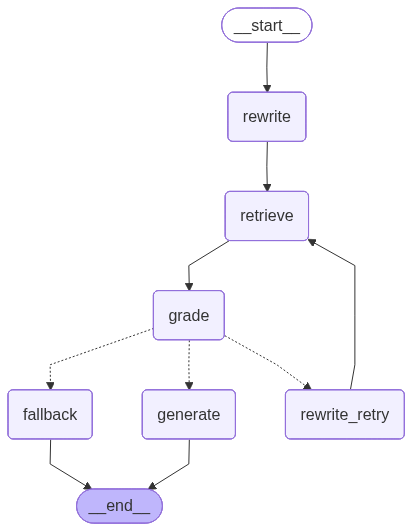

In [43]:
app

## 실행테스트 

In [44]:
initial_state = {
    "query":       "2026년 GDP 성장률 전망치는 얼마인가요?",
    "retry_count": 0
}
final = app.invoke(initial_state)
print(f"\n[ 최종 답변 ]\n{final['answer']}")

[rewrite] 2026년 한국은행 경제전망 보고서에 따른 GDP 성장률 전망치는 얼마인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: good (재시도 횟수: 0)
[generate] 답변 생성 완료

[ 최종 답변 ]
2026년 GDP 성장률 전망치는 2.0%입니다.


In [45]:
initial_state = {
    "query":       "2030년 한국 부동산 시장 전망은?",
    "retry_count": 0
}
final = app.invoke(initial_state)
print(f"\n[ 최종 답변 ]\n{final['answer']}")

[rewrite] 2030년 한국 부동산 시장에 대한 한국은행 경제전망 보고서의 예측은 무엇인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 0)
[rewrite_retry] 재시도 1회 → 2030년 한국 부동산 시장에 대한 한국은행 경제전망 보고서의 예측은 무엇인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 1)
[rewrite_retry] 재시도 2회 → 2030년 한국 부동산 시장에 대한 한국은행 경제전망 보고서의 예측은 무엇인가요?
[retrieve] 3개 문서 검색
[grade] 품질 평가 결과: bad (재시도 횟수: 2)
[fallback] 재시도 초과 → 일반 답변 생성

[ 최종 답변 ]
[참고: 검색 품질이 낮을 수 있습니다]
보고서에서 확인되지 않습니다.
